# 01 — Factors & the `SDESystem` · Pricing & Greeks

Every model in `qabit` is built from **factors** — one SDE component each — assembled
into a single `SDESystem`. The same Monte-Carlo engine then prices vanilla and exotic
derivatives, validated against closed-form theory at each step.

This notebook is self-contained and runnable: it reconstructs the foundations the
later notebooks build on.

In [15]:
import math, gc
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm
from functools import partial
import os, sys

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
SRC = os.path.join(ROOT, "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)
torch.set_num_threads(4)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

from qabit import (
    SDESystem,
    GeometricBrownianFactor,
    HestonFactor,
    VasicekRateFactor,
    EventCalendar,
    Stock,
    EuropeanOption,
    Market,
    DiscountCurve,
    VolSurface,
)
from qabit.core.market.curve import MarketKeys
from qabit.core.market.curve import StochasticDiscountCurve
from qabit.core.analytics.ir.vasicek import vasicek_zcb
from qabit.core.analytics.equity.black_scholes import implied_vol
from qabit.core.products.derivatives.equity.lookback import FixedStrikeLookback
from qabit.core.products.derivatives.equity.cliquet import CliquetOption
from qabit.core.products.derivatives.equity.european_fwd import EuropeanForwardOption
from qabit.core.portfolio.portfolio import Portfolio

# palette
B, O, G, P_, GREY, PURP = "#378ADD", "#D85A30", "#1D9E75", "#7F77DD", "#9aa0a6", "#9C27B0"

# annuitant entry age (years) — used by the Gompertz/Weibull laws
ENTRY_AGE = 60.0


## 1. GBM — log-normal validation

**SDE** $dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$. At 50 000 paths over five years the
terminal distribution reproduces the analytic log-normal moments, and the
Monte-Carlo error on $E[S_T]$ decays at the textbook $O(N^{-1/2})$ rate.

E[log S_5]   MC=0.1507  theory=0.1500
Std[log S_5] MC=0.4473  theory=0.4472


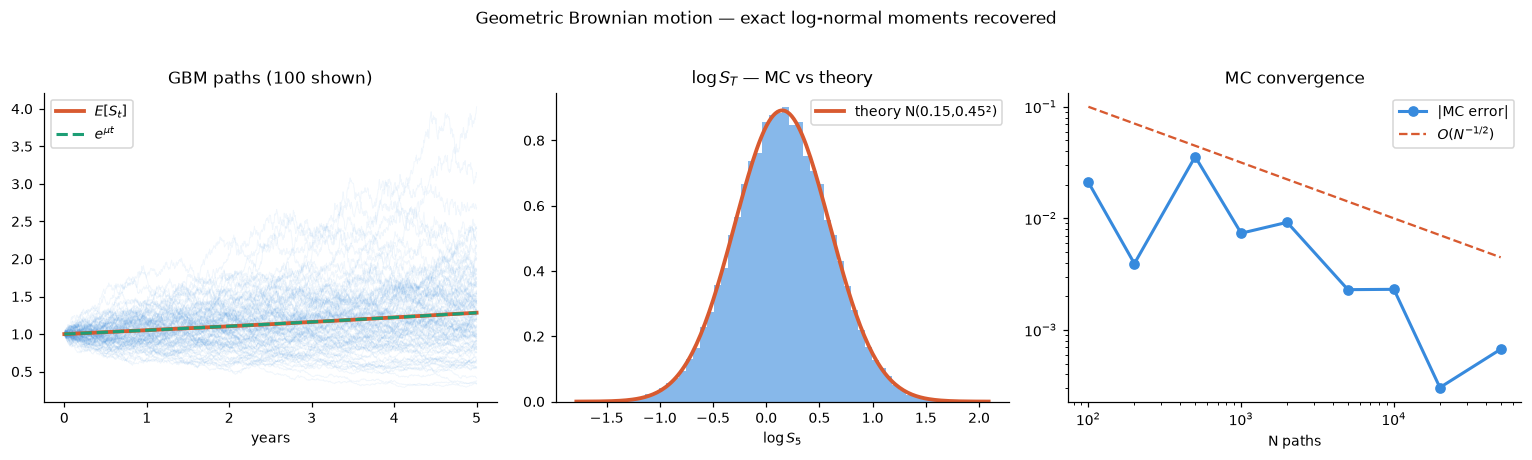

In [2]:
N = 50_000
sde = SDESystem({"gbm": GeometricBrownianFactor(sigma=0.20, s0=1.0, mu=0.05, rate=None)})
sde.simulate(EventCalendar.from_horizon(T=5.0, dt=1 / 252), n_paths=N, seed=42)
gbm = sde["gbm"]; st = gbm.get_state()
log_S = st.terminal().log().numpy(); t = st.dates.numpy()
print(f"E[log S_5]   MC={log_S.mean():.4f}  theory={(0.05-0.02)*5:.4f}")
print(f"Std[log S_5] MC={log_S.std():.4f}  theory={0.20*5**0.5:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for i in range(0, N, N // 100):
    ax[0].plot(t, st.paths[i].numpy(), alpha=0.07, color=B, lw=0.6)
ax[0].plot(t, st.paths.mean(0).numpy(), color=O, lw=2.5, label=r"$E[S_t]$")
ax[0].plot(t, np.exp(0.05 * t), color=G, lw=2, ls="--", label=r"$e^{\mu t}$")
ax[0].set_title("GBM paths (100 shown)"); ax[0].set_xlabel("years"); ax[0].legend()
x = np.linspace(log_S.min(), log_S.max(), 200)
mu_th, sig_th = (0.05 - 0.02) * 5, 0.20 * 5**0.5
ax[1].hist(log_S, bins=60, density=True, color=B, alpha=0.6)
ax[1].plot(x, norm.pdf(x, mu_th, sig_th), color=O, lw=2.5, label=f"theory N({mu_th:.2f},{sig_th:.2f}²)")
ax[1].set_title(r"$\log S_T$ — MC vs theory"); ax[1].set_xlabel(r"$\log S_5$"); ax[1].legend()
ns = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50_000]
th = math.exp(0.05 * 5); err = [abs(float(st.terminal()[:n].mean()) - th) for n in ns]
ax[2].loglog(ns, err, "o-", color=B, lw=2, label="|MC error|")
ax[2].loglog(ns, [1 / n**0.5 for n in ns], "--", color=O, lw=1.5, label=r"$O(N^{-1/2})$")
ax[2].set_xlabel("N paths"); ax[2].set_title("MC convergence"); ax[2].legend()
fig.suptitle("Geometric Brownian motion — exact log-normal moments recovered", y=1.03)
fig.tight_layout(); plt.show()

## 2. Heston — stochastic-volatility smile

**Heston (1993)** CIR-variance system. Pricing a strip of calls off the simulated
terminal distribution and inverting Black–Scholes gives a downward-sloping
implied-vol curve (the leverage skew from $\rho=-70\%$), while a flat GBM stays pinned.

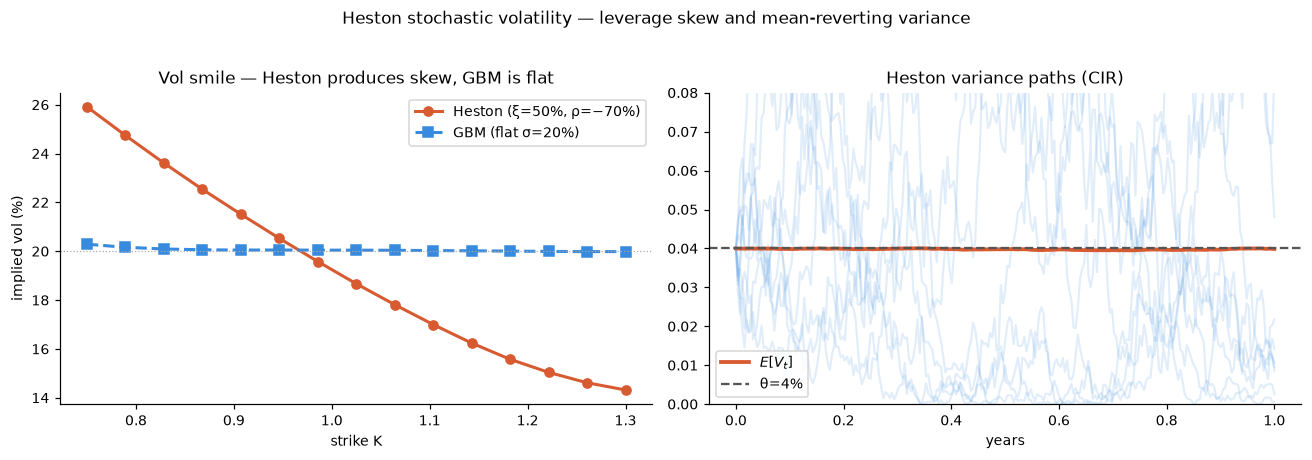

In [3]:
hes = SDESystem({"heston": HestonFactor(kappa=2.0, theta=0.04, xi=0.50, rho=-0.70,
                                        s0=1.0, v0=0.04, mu=0.05, rate=None)})
hes.simulate(EventCalendar.from_horizon(T=1.0, dt=1 / 252), n_paths=50_000, seed=42)
h = hes["heston"]
gb = SDESystem({"gbm": GeometricBrownianFactor(sigma=0.20, s0=1.0, mu=0.05, rate=None)})
gb.simulate(EventCalendar.from_horizon(T=1.0, dt=1 / 252), n_paths=100_000, seed=42)
g = gb["gbm"]
strikes = np.linspace(0.75, 1.30, 15)

def ivs(proc):
    out = []; S_T = proc.get_state().terminal()
    if S_T.dim() == 2: S_T = S_T[:, 0]
    for K in strikes:
        px = float(torch.relu(S_T - K).mean()) * math.exp(-0.05)
        iv = implied_vol(px, 1.0, float(K), 0.05, 1.0, is_call=True)
        out.append(iv * 100 if iv else np.nan)
    return out

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(strikes, ivs(h), "o-", color=O, lw=2, label="Heston (ξ=50%, ρ=−70%)")
ax[0].plot(strikes, ivs(g), "s--", color=B, lw=2, label="GBM (flat σ=20%)")
ax[0].axhline(20, color="#aaa", lw=0.8, ls=":")
ax[0].set_xlabel("strike K"); ax[0].set_ylabel("implied vol (%)")
ax[0].set_title("Vol smile — Heston produces skew, GBM is flat"); ax[0].legend()
st_h = h.get_state(); t1 = st_h.dates.float().numpy()
V = st_h.paths[:, :, 1] if st_h.paths.dim() == 3 else st_h.paths
for i in range(0, 1000, 100):
    ax[1].plot(t1, V[i].numpy(), color=B, alpha=0.15, lw=1.4)
ax[1].plot(t1, V.mean(0).numpy(), color=O, lw=2.5, label=r"$E[V_t]$")
ax[1].axhline(0.04, color="#555", lw=1.5, ls="--", label="θ=4%")
ax[1].set_ylim(0, 0.08); ax[1].set_title("Heston variance paths (CIR)")
ax[1].set_xlabel("years"); ax[1].legend()
fig.suptitle("Heston stochastic volatility — leverage skew and mean-reverting variance", y=1.03)
fig.tight_layout(); plt.show()

## 3. Vasicek — yield curve via a ZCB portfolio

**Vasicek (1977)** short rate. From one simulation we recover the full term-structure
behaviour: normal / flat / inverted curves; the realised yield-curve fan; the
maturity-correlation of bond prices; and the analytic duration
$B(T)=(1-e^{-\kappa T})/\kappa$, whose empirical bump-and-reprice counterpart matches
it and saturates at $1/\kappa$.

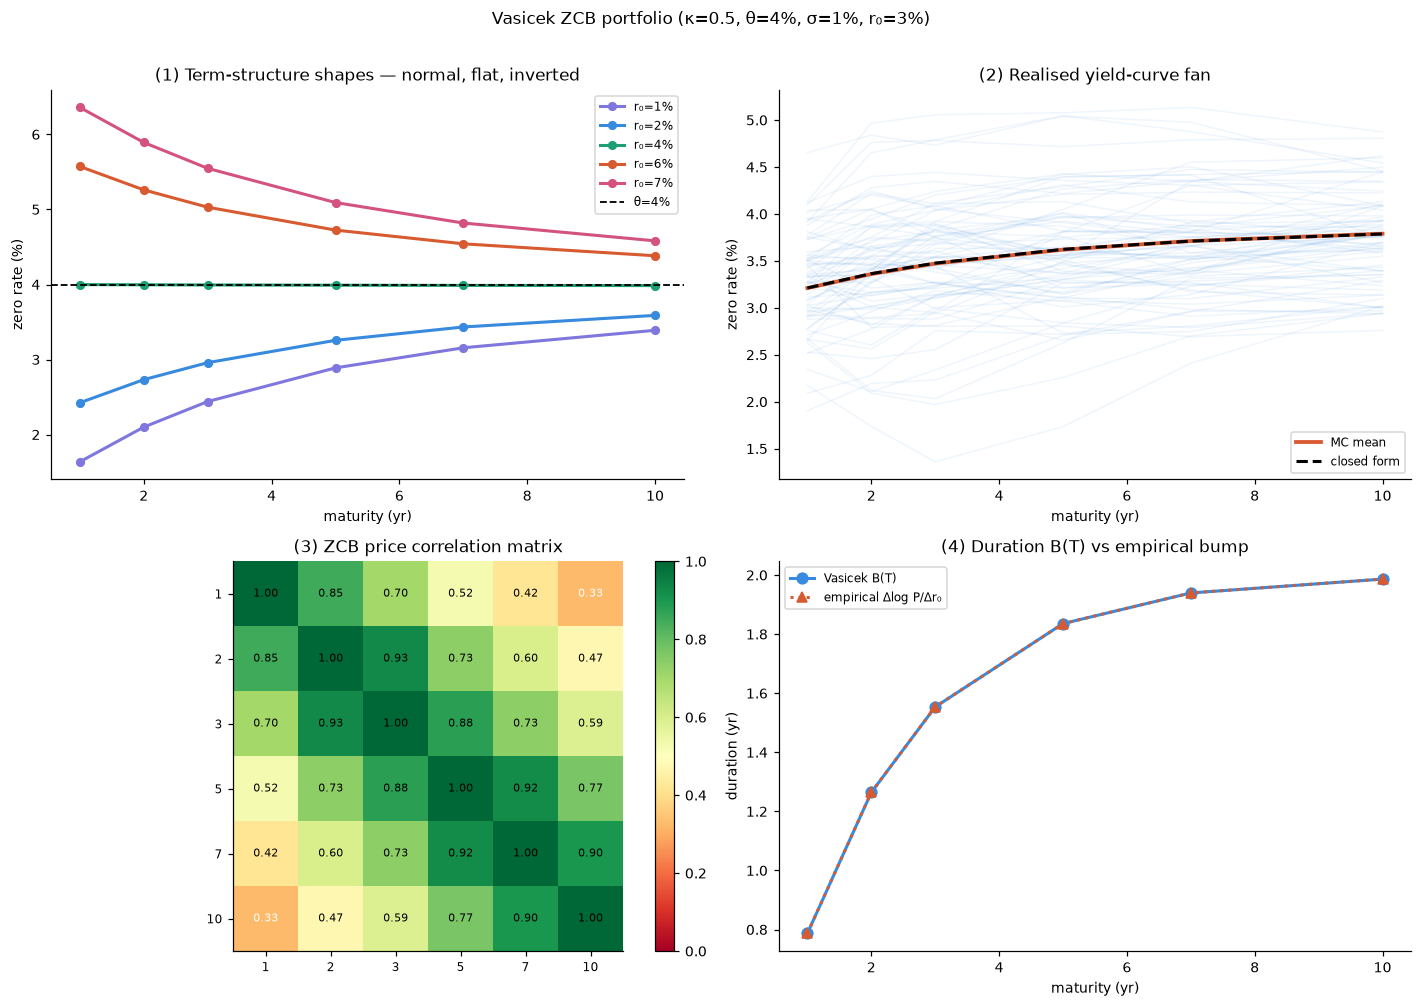

24605

In [4]:
kappa, theta, sigma_r, r0 = 0.5, 0.04, 0.01, 0.03
mats = [1, 2, 3, 5, 7, 10]
vas = SDESystem({"rate": VasicekRateFactor(kappa=kappa, theta=theta, sigma=sigma_r, r0=r0)})
cal = EventCalendar.from_horizon(T=10.0, dt=1 / 52)
vas.simulate(cal, n_paths=20_000, seed=42)
sdc = StochasticDiscountCurve(vas["rate"])
P = torch.stack([sdc.df(T) for T in mats], dim=1)
mc = P.mean(0).numpy(); cf = [vasicek_zcb(r0, kappa, theta, sigma_r, T) for T in mats]

fig, axes = plt.subplots(2, 2, figsize=(13, 9)); axes = axes.flat
for r0v, col in zip([0.01, 0.02, 0.04, 0.06, 0.07], [P_, B, G, O, PK]):
    zr = [100 * (-math.log(vasicek_zcb(r0v, kappa, theta, sigma_r, T)) / T) for T in mats]
    axes[0].plot(mats, zr, "-o", color=col, lw=2, ms=5, label=f"r₀={r0v*100:.0f}%")
axes[0].axhline(theta * 100, color="k", lw=1.2, ls="--", label=f"θ={theta*100:.0f}%")
axes[0].set_title("(1) Term-structure shapes — normal, flat, inverted")
axes[0].set_xlabel("maturity (yr)"); axes[0].set_ylabel("zero rate (%)"); axes[0].legend(fontsize=8)
for i in range(80):
    zr_path = [-math.log(max(float(P[i * 75, j]), 1e-9)) / mats[j] * 100 for j in range(len(mats))]
    axes[1].plot(mats, zr_path, alpha=0.08, color=B, lw=1.0)
axes[1].plot(mats, [100 * (-math.log(m) / T) for T, m in zip(mats, mc)], color=O, lw=2.5, label="MC mean")
axes[1].plot(mats, [100 * (-math.log(c) / T) for T, c in zip(mats, cf)], "k--", lw=2, label="closed form")
axes[1].set_title("(2) Realised yield-curve fan"); axes[1].set_xlabel("maturity (yr)")
axes[1].set_ylabel("zero rate (%)"); axes[1].legend(fontsize=8)
corr = torch.corrcoef(P.T).numpy()
im = axes[2].imshow(corr, cmap="RdYlGn", vmin=0, vmax=1)
axes[2].set_xticks(range(len(mats))); axes[2].set_xticklabels(mats, fontsize=8)
axes[2].set_yticks(range(len(mats))); axes[2].set_yticklabels(mats, fontsize=8)
for i in range(len(mats)):
    for j in range(len(mats)):
        axes[2].text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=7,
                     color="k" if corr[i, j] > 0.4 else "w")
plt.colorbar(im, ax=axes[2], fraction=0.046); axes[2].set_title("(3) ZCB price correlation matrix")
Bfun = lambda T: (1 - math.exp(-kappa * T)) / kappa
eps = 1e-3; dur = {}
for bump in [r0 - eps, r0 + eps]:
    vb = SDESystem({"rate": VasicekRateFactor(kappa=kappa, theta=theta, sigma=sigma_r, r0=bump)})
    vb.simulate(cal, n_paths=20_000, seed=42); sb = StochasticDiscountCurve(vb["rate"])
    dur[bump] = torch.stack([sb.df(T) for T in mats], dim=1).mean(0)
de = [float(-(dur[r0 + eps][i].log() - dur[r0 - eps][i].log()) / (2 * eps)) for i in range(len(mats))]
axes[3].plot(mats, [Bfun(T) for T in mats], "o-", color=B, lw=2, ms=7, label="Vasicek B(T)")
axes[3].plot(mats, de, "^:", color=O, lw=2, ms=7, label="empirical Δlog P/Δr₀")
axes[3].set_title("(4) Duration B(T) vs empirical bump"); axes[3].set_xlabel("maturity (yr)")
axes[3].set_ylabel("duration (yr)"); axes[3].legend(fontsize=8)
fig.suptitle(f"Vasicek ZCB portfolio (κ={kappa}, θ={theta*100:.0f}%, σ={sigma_r*100:.0f}%, r₀={r0*100:.0f}%)", y=1.01)
fig.tight_layout(); plt.show(); del P, dur; gc.collect()

## 5. Exotics — path-dependency from the same paths

Because every product reads the same simulated paths, an exotic payoff is a different
reducer over the path, not a different engine. Below: a fixed-strike **lookback** (pays
the running maximum), a **cliquet** (sum of capped/floored period returns), and a
**forward-start** option (BSM and MC agree).

Lookback 0.3021  vs  European 0.1613  (premium 0.1408)


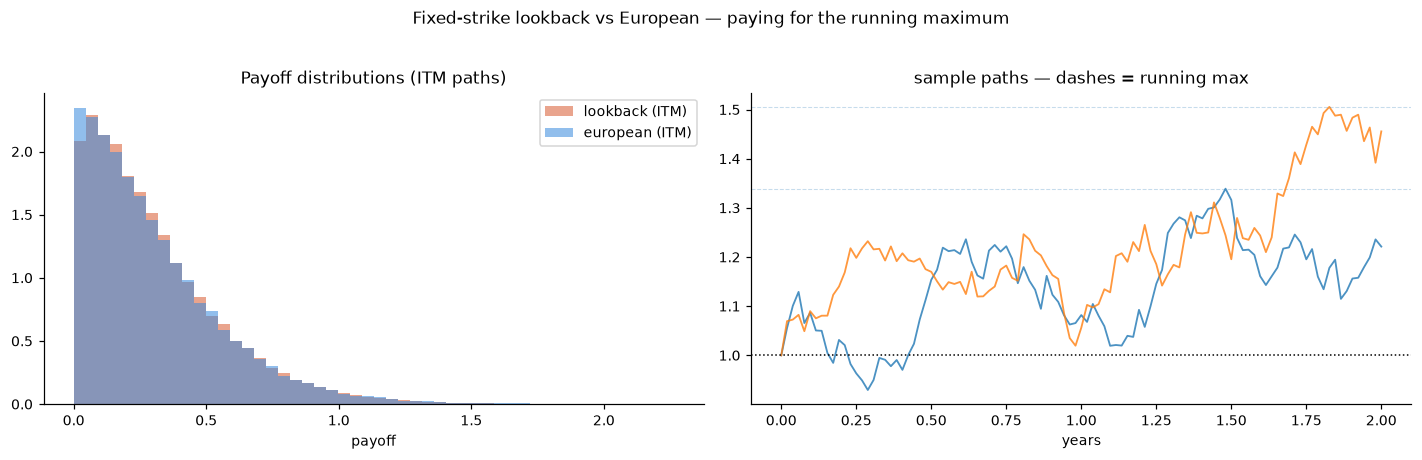

12458

In [6]:
N = 50_000
s = SDESystem({"gbm": GeometricBrownianFactor(sigma=0.20, s0=1.0, mu=0.05, rate=None)})
g = s["gbm"]; S = Stock(g)
lb = FixedStrikeLookback(S, strike=1.0, maturity=2.0)
euro = EuropeanOption(S, strike=1.0, maturity=2.0)
ptf = Portfolio(system=s, products=[lb, euro]); ptf.simulate(n_paths=N, dt=1 / 52, seed=42)
mkt = Market(discount={"ois": DiscountCurve.flat(0.05)},
             volatility={"v": VolSurface.flat(0.20, K_min=0.5, K_max=2.0, T_max=3.0)})
prices = list(ptf.price(mkt).quotes.values()); payoffs = ptf.mc_payoff().numpy()
print(f"Lookback {prices[0]:.4f}  vs  European {prices[1]:.4f}  (premium {prices[0]-prices[1]:.4f})")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for i, (lab, col) in enumerate([("lookback", O), ("european", B)]):
    p = payoffs[:, i]; p = p[p > 1e-4]
    ax[0].hist(p, bins=50, density=True, alpha=0.55, color=col, label=f"{lab} (ITM)")
ax[0].set_title("Payoff distributions (ITM paths)"); ax[0].set_xlabel("payoff"); ax[0].legend()
t3 = g.get_state().dates.float().numpy()
for i in range(2):
    pth = g.get_state().paths[i * 200].numpy()
    ax[1].plot(t3, pth, lw=1.2, alpha=0.8); ax[1].axhline(pth.max(), alpha=0.25, lw=0.7, ls="--")
ax[1].axhline(1.0, color="k", lw=1, ls=":"); ax[1].set_xlabel("years")
ax[1].set_title("sample paths — dashes = running max")
fig.suptitle("Fixed-strike lookback vs European — paying for the running maximum", y=1.03)
fig.tight_layout(); plt.show(); del ptf; gc.collect()

Cliquet price (cap=8%, floor=-4%): 0.1205


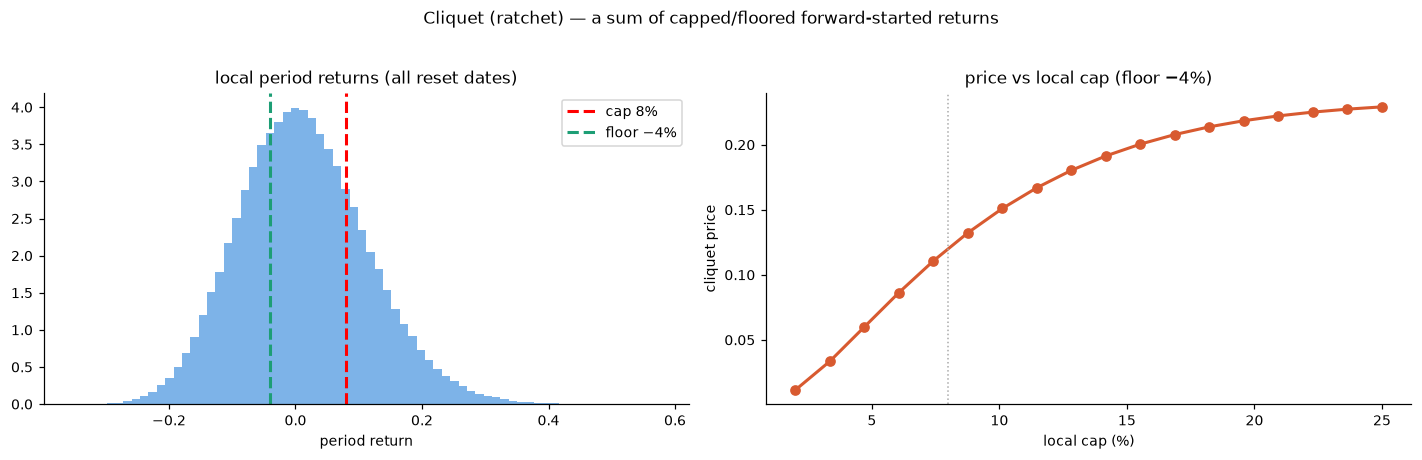

10767

In [7]:
s4 = SDESystem({"gbm": GeometricBrownianFactor(sigma=0.20, s0=1.0, mu=0.05, rate=None)})
S4 = Stock(s4["gbm"]); sched = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2.0]
cliq = CliquetOption(S4, schedule=sched, local_cap=0.08, local_floor=-0.04)
p4 = Portfolio(system=s4, products=[cliq]); p4.simulate(n_paths=50_000, dt=1 / 52, seed=42)
mkt4 = Market(discount={"ois": DiscountCurve.flat(0.05)})
base_px = float(cliq._mc_price_zero(mkt4).mean())
print(f"Cliquet price (cap=8%, floor=-4%): {base_px:.4f}")
spots = S4.at_dates([0.0] + sched); local = (spots[:, 1:] / spots[:, :-1] - 1.0).numpy().flatten()
caps = np.linspace(0.02, 0.25, 18)
pc = [float(CliquetOption(S4, schedule=sched, local_cap=float(c), local_floor=-0.04)._mc_price_zero(mkt4).mean()) for c in caps]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(local, bins=70, density=True, color=B, alpha=0.65)
ax[0].axvline(0.08, color="r", lw=2, ls="--", label="cap 8%"); ax[0].axvline(-0.04, color=G, lw=2, ls="--", label="floor −4%")
ax[0].set_title("local period returns (all reset dates)"); ax[0].set_xlabel("period return"); ax[0].legend()
ax[1].plot(caps * 100, pc, "o-", color=O, lw=2); ax[1].axvline(8, color="#aaa", lw=1, ls=":")
ax[1].set_xlabel("local cap (%)"); ax[1].set_ylabel("cliquet price"); ax[1].set_title("price vs local cap (floor −4%)")
fig.suptitle("Cliquet (ratchet) — a sum of capped/floored forward-started returns", y=1.03)
fig.tight_layout(); plt.show(); del p4; gc.collect()

BSM vs MC gap (ATM fwd-start): 0.00011269748210906982


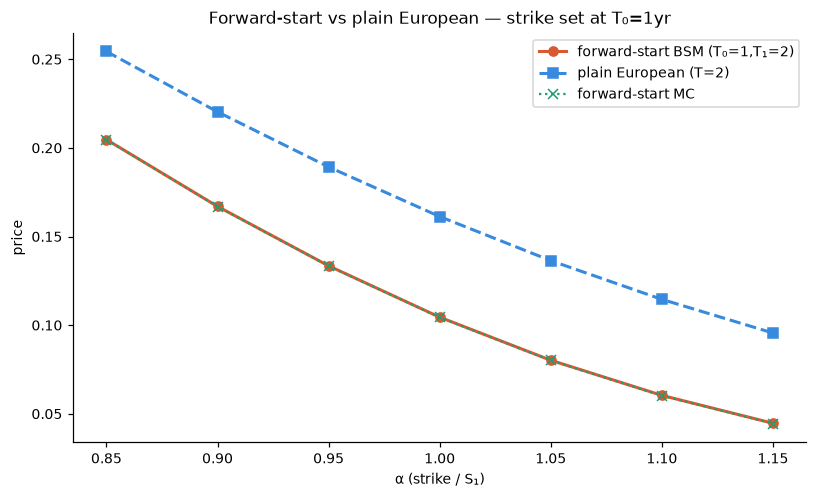

In [8]:
s5 = SDESystem({"gbm": GeometricBrownianFactor(sigma=0.20, s0=1.0, mu=0.05, rate=None)})
S5 = Stock(s5["gbm"]); alphas = [0.85, 0.90, 0.95, 1.0, 1.05, 1.10, 1.15]
fwds = [EuropeanForwardOption(S5, alpha=a, T0=1.0, T1=2.0) for a in alphas]
plains = [EuropeanOption(S5, strike=a, maturity=2.0) for a in alphas]
p5 = Portfolio(system=s5, products=fwds + plains); p5.simulate(n_paths=120_000, dt=1 / 52, seed=42)
mkt5 = Market(discount={"ois": DiscountCurve.flat(0.05)},
              volatility={"v": VolSurface.flat(0.20, K_min=0.5, K_max=2.0, T_max=3.0)})
pf = [float(f.price(mkt5)[0].mean()) for f in fwds]
pp = [float(p.price(mkt5)[0].mean()) for p in plains]
pfm = [float(f._mc_price_zero(mkt5).mean()) for f in fwds]
print("BSM vs MC gap (ATM fwd-start):", abs(pf[3] - pfm[3]))

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(alphas, pf, "o-", color=O, lw=2, label="forward-start BSM (T₀=1,T₁=2)")
ax.plot(alphas, pp, "s--", color=B, lw=2, label="plain European (T=2)")
ax.plot(alphas, pfm, "x:", color=G, lw=1.5, label="forward-start MC")
ax.set_xlabel("α (strike / S₁)"); ax.set_ylabel("price")
ax.set_title("Forward-start vs plain European — strike set at T₀=1yr"); ax.legend()
fig.tight_layout(); plt.show()

In [16]:
from qabit import (
    SDESystem,
    GeometricBrownianFactor,
    VasicekRateFactor,
    EventCalendar,
    Market,
    DiscountCurve,
    VolSurface,
    ExponentialHazardFactor,
    GompertzHazardFactor,
    WeibullHazardFactor,
    CIRExponentialHazardFactor,
    CIRGompertzHazardFactor,
    CIRWeibullHazardFactor,
)

from qabit.core.analytics.hazard import (
    exponential_hazard,
    gompertz_hazard,
    weibull_hazard,
    survival as hz_survival,
    density as hz_density,
    expected_lifetime as hz_expected_lifetime,
)

from qabit.core.market.curve import (
    MarketKeys,
    StochasticDiscountCurve,
    StochasticHazardCurve,
    HazardCurve,
)

class MortalityModel:
    """Notebook adapter binding a deterministic hazard *law* (and its qabit
    Factor) to the qabit analytics — recreating the rich interface the retired
    ``HazardProcess`` objects exposed:

    * closed-form survival / density / E[tau] / lambda on a years-since-inception grid;
    * Monte-Carlo death times drawn from the simulated intensity via an
      ``SDESystem`` and ``StochasticHazardCurve`` (genuinely stochastic for the
      CIR variants, degenerate for the deterministic ones).

    The factor is the *only* simulation object; this wrapper is pure notebook
    glue so the Titanic/GMDB analyses read as they did before the Process→Factor
    rename.
    """

    def __init__(self, label, color, hazard_fn, factor):
        self.label, self.color = label, color
        self.hazard_fn, self.factor = hazard_fn, factor
        self._sde = None
        self._curve = None

    @staticmethod
    def _t(t):
        return t if torch.is_tensor(t) else torch.as_tensor(t, dtype=torch.float32)

    # ── closed-form survival family (deterministic target law) ────────────────
    def hazard_rate(self, t):
        return self.hazard_fn(self._t(t))

    def survival(self, t):
        t = self._t(t)
        return hz_survival(t, self.hazard_fn(t))

    def density(self, t):
        t = self._t(t)
        return hz_density(t, self.hazard_fn(t))

    def expected_lifetime(self, t):
        t = self._t(t)
        return hz_expected_lifetime(t, self.hazard_fn(t))

    # ── Monte-Carlo death times via the SDESystem ─────────────────────────────
    def simulate(self, dates, n_paths, seed=11):
        cal = EventCalendar(self._t(dates))
        sde = SDESystem({"mort": self.factor})
        sde.simulate(cal, n_paths=n_paths, seed=seed)
        self._sde = sde  # keep alive: factor views hold only a weakref
        self._curve = StochasticHazardCurve(sde["mort"])
        return self

    def simulate_death_times(self, seed=None):
        if self._curve is None:
            raise RuntimeError("call simulate(dates, n_paths) first")
        return self._curve.tau(seed=seed)

## 6. Six mortality models: three deterministic laws and their CIR-stochastic counterparts

In [ ]:
# Each MortalityModel binds a hazard law (closed-form survival
# family) to the matching qabit hazard Factor (Monte-Carlo death times).
models = {
    "exp": MortalityModel(
        "exp", B,
        partial(exponential_hazard, lambda0=0.05),
        ExponentialHazardFactor(lambda0=0.05),
    ),
    "gompertz": MortalityModel(
        "gompertz", O,
        partial(gompertz_hazard, m=80.0, b=9.5, entry_age=ENTRY_AGE),
        GompertzHazardFactor(m=80.0, b=9.5, entry_age=ENTRY_AGE),
    ),
    "weibull": MortalityModel(
        "weibull", G,
        partial(weibull_hazard, c1=90.43, c2=10.36, entry_age=ENTRY_AGE),
        WeibullHazardFactor(c1=90.43, c2=10.36, entry_age=ENTRY_AGE),
    ),
    "cir-exp": MortalityModel(
        "cir-exp", P_,
        partial(exponential_hazard, lambda0=0.05),
        CIRExponentialHazardFactor(lambda0=0.05, kappa=0.5, sigma_lam=0.03),
    ),
    "cir-gomp": MortalityModel(
        "cir-gomp", GREY,
        partial(gompertz_hazard, m=80.0, b=9.5, entry_age=ENTRY_AGE),
        CIRGompertzHazardFactor(m=80.0, b=9.5, kappa=0.5, sigma_lam=0.025, entry_age=ENTRY_AGE),
    ),
    "cir-weib": MortalityModel(
        "cir-weib", PURP,
        partial(weibull_hazard, c1=90.43, c2=10.36, entry_age=ENTRY_AGE),
        CIRWeibullHazardFactor(c1=90.43, c2=10.36, kappa=0.5, sigma_lam=0.02, entry_age=ENTRY_AGE),
    ),
}

T50 = torch.linspace(0.0, 50.0, 501)
T300 = torch.linspace(0.0, 300.0, 3001)
N = 5_000
sigma, r, k = 0.20, 0.06, 0.01

# Simulate every model on a shared fine calendar — one line, no mock product.
cal = EventCalendar.from_horizon(50.0, dt=0.1)
dates = cal.as_tensor()
for m in models.values():
    m.simulate(dates, N)


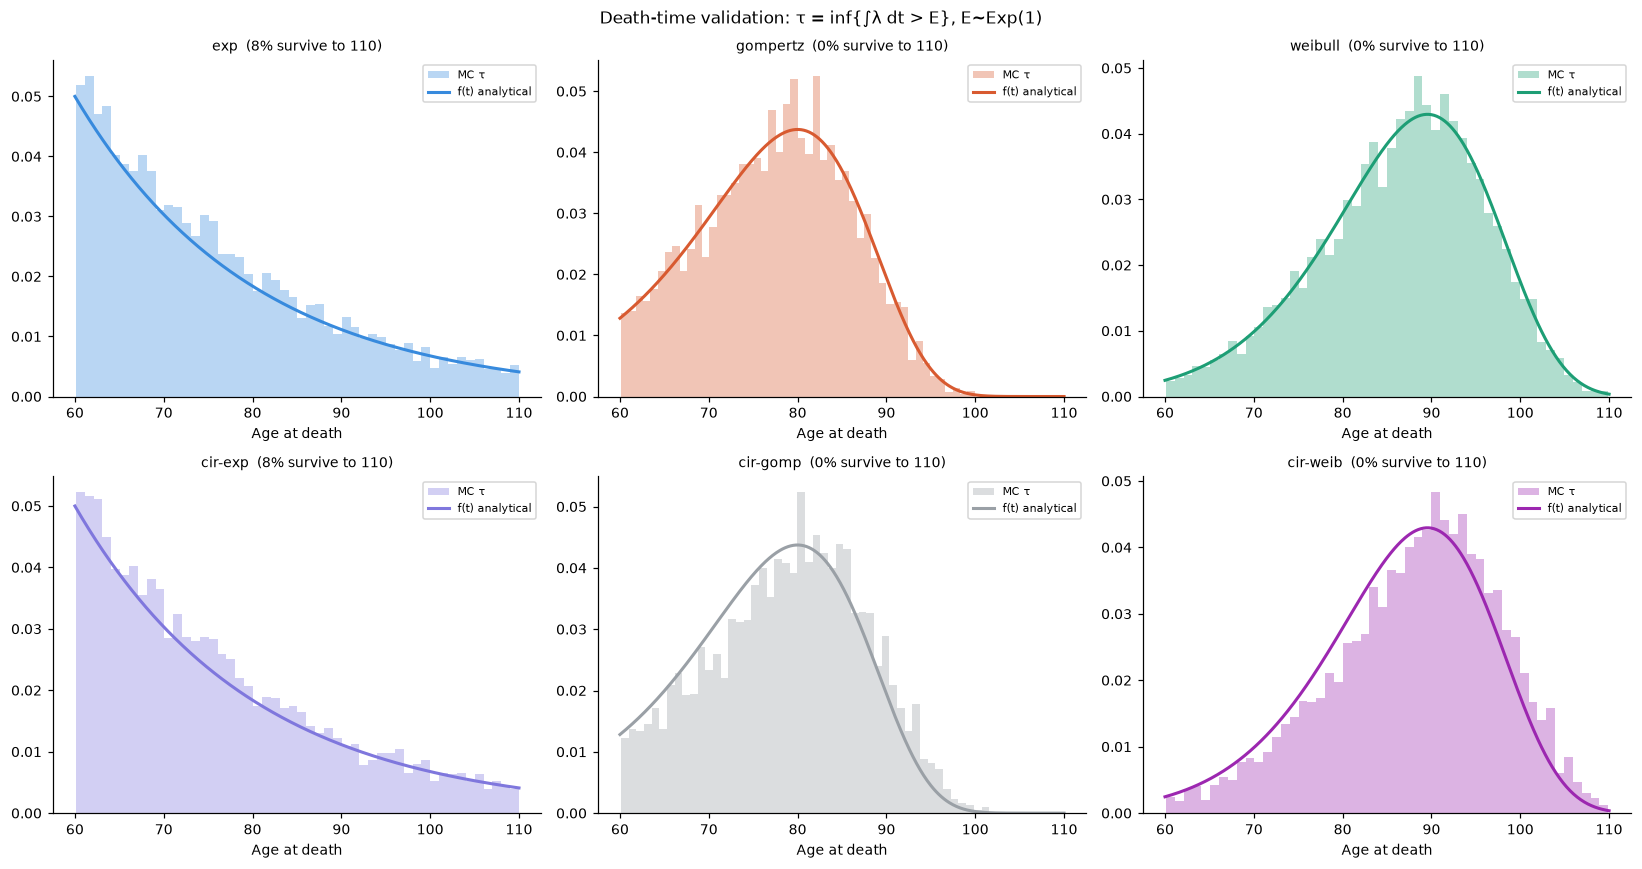

In [19]:
# Death-time validation: simulate tau by integrated-hazard inversion, histogram
# it, and overlay the analytical density f(t)=lambda(t)S(t).  age = entry age + t.
age = (T50 + ENTRY_AGE).numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), facecolor="white")
for ax, (name, m) in zip(axes.flat, models.items()):
    tau = m.simulate_death_times(seed=42).numpy()
    died = tau[tau <= 50.0] + ENTRY_AGE
    ax.hist(died, bins=50, density=True, color=m.color, alpha=0.35, label="MC τ")
    ax.plot(age, m.density(T50).numpy(), color=m.color, lw=2, label="f(t) analytical")
    pct = 100.0 * np.mean(tau > 50.0)
    ax.set_title(f"{m.label}  ({pct:.0f}% survive to 110)", fontsize=9)
    ax.set_xlabel("Age at death")
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Death-time validation: τ = inf{∫λ dt > E}, E~Exp(1)", fontsize=11)
fig.tight_layout()
plt.show()

### Takeaway

One factor abstraction, one simulation call, one Monte-Carlo engine — validated against
closed-form theory for GBM moments, the Heston smile, the Vasicek curve, correlated
dynamics, and three families of path-dependent exotics. Everything that follows is
assembled from exactly these pieces.